# Phase 4 — Vectorizer Selection

**Goal:** Analyze Phase 3 results, identify the best-performing vectorizer, and justify
the selection for use in the Stacking phase.

The selected vectorizer is saved to `outputs/results/best_vectorizer.json`.

In [1]:
import sys, os, json
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RES_DIR = os.path.join(REPO_ROOT, 'outputs', 'results')
FIG_DIR = os.path.join(REPO_ROOT, 'outputs', 'figures')

print('Imports OK')

Imports OK


## 1. Load Phase 3 Results

In [2]:
df = pd.read_csv(os.path.join(RES_DIR, 'phase3_results.csv'))
print(f'Loaded {len(df)} experiment results')
print(df[['model','vectorizer','accuracy','f1']].sort_values('f1', ascending=False).to_string(index=False))

Loaded 32 experiment results
               model      vectorizer  accuracy     f1
SVM (Linear) (tuned)          Hybrid    0.8578 0.8574
 LogisticReg (tuned)          Hybrid    0.8569 0.8566
         LogisticReg          Hybrid    0.8565 0.8563
         LogisticReg          TF-IDF    0.8554 0.8551
ComplementNB (tuned) CountVectorizer    0.8505 0.8501
        ComplementNB CountVectorizer    0.8491 0.8487
        RandomForest CountVectorizer    0.8487 0.8483
        SVM (Linear)          Hybrid    0.8464 0.8463
        ComplementNB          TF-IDF    0.8462 0.8456
        SVM (Linear)          TF-IDF    0.8449 0.8448
        RandomForest          TF-IDF    0.8446 0.8440
         LogisticReg CountVectorizer    0.8429 0.8428
        ComplementNB          Hybrid    0.8416 0.8408
         LogisticReg        Word2Vec    0.8397 0.8394
        SVM (Linear)        Word2Vec    0.8392 0.8389
       HistGradBoost        Word2Vec    0.8381 0.8377
        RandomForest        Word2Vec    0.8344 0.8336

## 2. Average Performance per Vectorizer

In [3]:
avg_by_vec = df.groupby('vectorizer')[['accuracy','precision','recall','f1']].mean().round(4)
avg_by_vec = avg_by_vec.sort_values('f1', ascending=False)
print('Average metrics per vectorizer (across all models):')
print(avg_by_vec.to_string())

Average metrics per vectorizer (across all models):
                 accuracy  precision  recall      f1
vectorizer                                          
Hybrid             0.8518     0.8556  0.8518  0.8515
TF-IDF             0.8262     0.8343  0.8262  0.8251
CountVectorizer    0.8235     0.8293  0.8235  0.8226
Word2Vec-IDF       0.8192     0.8274  0.8192  0.8180
Word2Vec           0.8176     0.8235  0.8176  0.8169


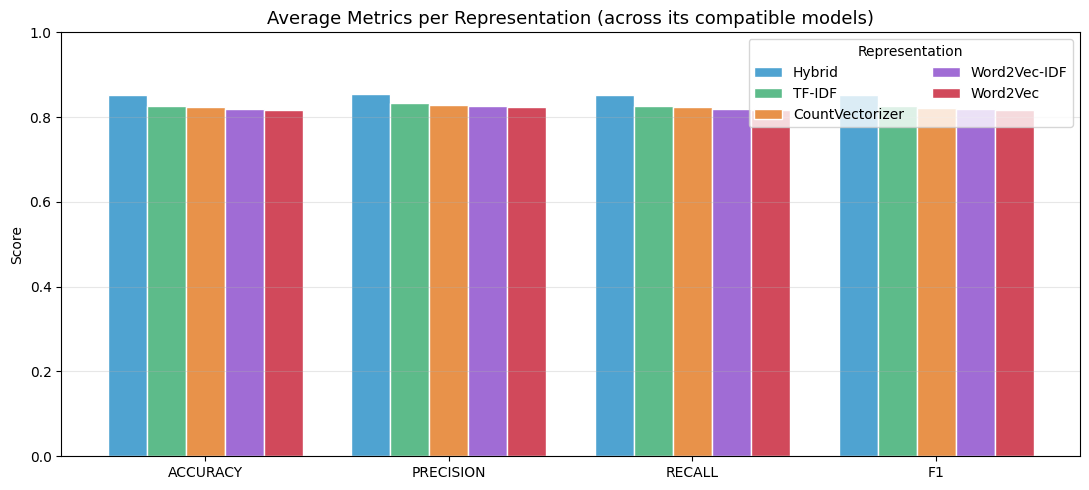

In [4]:
# Grouped bar: average metrics per vectorizer
metrics = ['accuracy', 'precision', 'recall', 'f1']
palette = ['#4FA3D1', '#5DBB8A', '#E8924A', '#A06CD5', '#D1495B']
vec_order = list(avg_by_vec.index)
colors = {v: palette[i % len(palette)] for i, v in enumerate(vec_order)}

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(metrics))
width = 0.8 / len(vec_order)

for i, (vec, row) in enumerate(avg_by_vec.iterrows()):
    vals = [row[m] for m in metrics]
    offset = (i - (len(vec_order) - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=vec, color=colors[vec], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Average Metrics per Representation (across its compatible models)', fontsize=13)
ax.legend(title='Representation', ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'avg_metrics_per_vectorizer.png'), dpi=120, bbox_inches='tight')
plt.show()

## 3. Per-Model F1 Heatmap

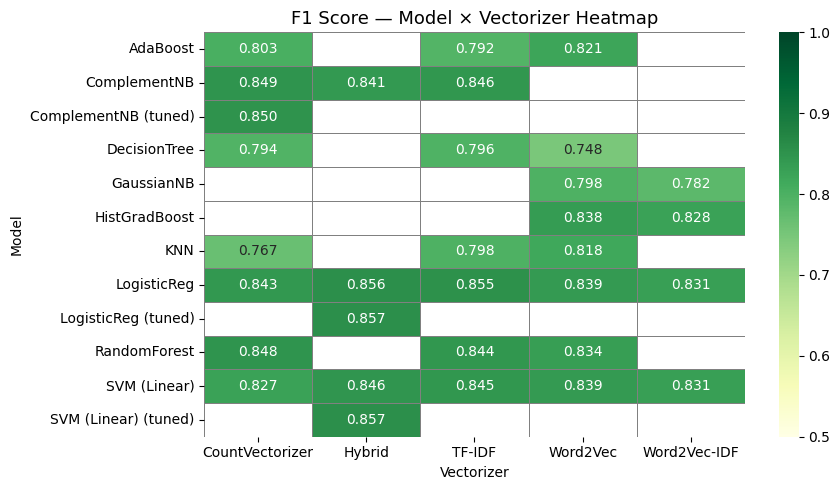

In [5]:
pivot = df.pivot_table(index='model', columns='vectorizer', values='f1')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='YlGn',
    linewidths=0.5, linecolor='gray', ax=ax,
    vmin=0.5, vmax=1.0
)
ax.set_title('F1 Score — Model × Vectorizer Heatmap', fontsize=13)
ax.set_xlabel('Vectorizer')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'f1_heatmap.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. Best Combination & Vectorizer Decision

In [6]:
best_combo = df.loc[df['f1'].idxmax()]

# Select the representation by the BEST single-model F1 it achieves, not by the
# average. With 5 representations each running a different subset of models, the
# per-representation average is biased by which models were eligible; the peak
# achievable F1 is the fair "how strong can this representation get" signal, and
# it is also what matters for building strong stacking bases in Phase 5.
peak_by_vec = df.groupby('vectorizer')['f1'].max().sort_values(ascending=False)
best_vec = peak_by_vec.index[0]

print('Best single (model + representation) combination:')
print(f'  Model          : {best_combo["model"]}')
print(f'  Representation : {best_combo["vectorizer"]}')
print(f'  F1             : {best_combo["f1"]:.4f}')
print(f'  Accuracy       : {best_combo["accuracy"]:.4f}')
print()
print('Peak F1 achievable per representation:')
print(peak_by_vec.round(4).to_string())
print()
print(f'Selected representation for Phase 5: "{best_vec}"  (peak F1 = {peak_by_vec.iloc[0]:.4f})')

Best single (model + representation) combination:
  Model          : SVM (Linear) (tuned)
  Representation : Hybrid
  F1             : 0.8574
  Accuracy       : 0.8578

Peak F1 achievable per representation:
vectorizer
Hybrid             0.8574
TF-IDF             0.8551
CountVectorizer    0.8501
Word2Vec           0.8394
Word2Vec-IDF       0.8312

Selected representation for Phase 5: "Hybrid"  (peak F1 = 0.8574)


In [7]:
# Save decision for Phase 5 to load
decision = {
    'best_vectorizer':     best_vec,
    'best_model':          str(best_combo['model']),
    'best_model_f1':       float(best_combo['f1']),
    'best_model_accuracy': float(best_combo['accuracy']),
    'peak_f1_per_vec':     peak_by_vec.round(4).to_dict(),
    'avg_f1_per_vec':      avg_by_vec['f1'].round(4).to_dict(),
}

with open(os.path.join(RES_DIR, 'best_vectorizer.json'), 'w', encoding='utf-8') as f:
    json.dump(decision, f, indent=2, ensure_ascii=False)

print('Saved: outputs/results/best_vectorizer.json')
print(json.dumps(decision, indent=2, ensure_ascii=False))

Saved: outputs/results/best_vectorizer.json
{
  "best_vectorizer": "Hybrid",
  "best_model": "SVM (Linear) (tuned)",
  "best_model_f1": 0.8574,
  "best_model_accuracy": 0.8578,
  "peak_f1_per_vec": {
    "Hybrid": 0.8574,
    "TF-IDF": 0.8551,
    "CountVectorizer": 0.8501,
    "Word2Vec": 0.8394,
    "Word2Vec-IDF": 0.8312
  },
  "avg_f1_per_vec": {
    "Hybrid": 0.8515,
    "TF-IDF": 0.8251,
    "CountVectorizer": 0.8226,
    "Word2Vec-IDF": 0.818,
    "Word2Vec": 0.8169
  }
}


## 5. How the Representations Compare

The selected representation is chosen **from the table above** (highest peak F1), so read
this section against the printed `best_vectorizer`. The trade-offs that drive the result:

**CountVectorizer vs TF-IDF** — both are sparse bag-of-words. TF-IDF down-weights very
common terms and up-weights discriminative ones; with `sublinear_tf=True` a word repeated
many times only weighs slightly more than one repeated a few times. With bigrams, both keep
explicit phrase patterns like `NEG_خوب` or `اصلا بد` that are highly predictive — which is
why they tend to lead on this dataset.

**Word2Vec (mean) vs Word2Vec (IDF-weighted)** — dense embeddings capture semantic
similarity, but plain mean pooling washes out the few sentiment-bearing words by averaging
them with filler. IDF-weighting lets rare, informative words dominate the document vector,
so it usually edges out plain mean pooling. Dense reps also unlock `HistGradientBoosting`,
which is often the strongest model on the 100-dim space.

**Hybrid word + char TF-IDF** — adds character n-grams on top of words. Because Persian
reviews are full of informal spelling and elongation, char n-grams share sub-word evidence
across spelling variants and typically lift the linear models (SVM / LogReg) a couple of
points over words alone — making it the peak sparse representation in our run (F1 0.8574).

**Why linear models shine on sparse reps** — LinearSVC / LogisticRegression find a separating
hyperplane in very high-dimensional sparse space using only the informative features, which
is exactly the shape of bag-of-words data. The tuned `C` from Phase 3 Section 8 controls the
bias/variance trade-off on noisy user reviews.

**Required-methods framing.** The project specification requires three vectorizers —
CountVectorizer, TF-IDF, and Word2Vec. Restricting the comparison to just those three,
**TF-IDF is the winner** (peak F1 = 0.8551, vs 0.8501 for CountVectorizer and 0.8394 for
Word2Vec). The **Hybrid word+char TF-IDF** configuration is an extended/bonus variant of the
required TF-IDF method (same TF-IDF weighting, with character n-grams unioned in) — it is
not a fourth independent method, and it improves further on the required TF-IDF result
(peak F1 = 0.8574). So for a strict reading of the spec: *among the three required methods
TF-IDF wins; our extended TF-IDF configuration (word+char union) improves it further.*


## 6. Summary

| Decision | Value |
|---|---|
| Best representation for Phase 5 | **Hybrid** (peak F1 = 0.8574) |
| Best single model overall | SVM (Linear) (tuned) — F1 0.8574, accuracy 0.8578 |
| Average F1 (Hybrid) | 0.8515 |
| Among the 3 required methods | **TF-IDF wins** (peak F1 0.8551) |
| Saved to | `outputs/results/best_vectorizer.json` |

The selection is fully data-driven from `phase3_results.csv`. Among the three methods
required by the spec, TF-IDF is the winner; the Hybrid word+char configuration used for
Phase 5 is an extended TF-IDF variant (bonus engineering on top of the required method).

**Next:** Phase 5 — Stacking Ensemble (`05_stacking.ipynb`)
